# Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scapy.all import raw, PcapReader, Ether

In [2]:
import sys
sys.path.append("../")

from utils.seed_all import seed_all

DEFAULT_SEED = 10
seed_all(DEFAULT_SEED)

In [3]:
raw_x_path      = "../data/tow-ids-dataset/raw/Automotive_Ethernet_with_Attack_original_10_17_19_50_training.pcap"
raw_y_path      = "../data/tow-ids-dataset/raw/y_train.csv"
number_of_bytes = 58

In [4]:
#raw_packets = rdpcap(raw_x_path)

In [4]:
labels = pd.read_csv(raw_y_path, header=None, names=["index", "class", "label"])
labels['label'] = labels['label'].map({
    'Normal': 'Normal',
    'C_D': 'CAN DoS',
    'P_I': 'PTP Sync',
    'M_F': 'Switch MAC Flooding',
    'F_I': 'Frame Injection',
    'C_R': 'CAN Replay',
})

In [ ]:
def detect_protocol_scapy(pkt):
        """Detect protocol using Scapy's layer inspection."""
        eth_type = pkt[Ether].type

        if eth_type in [2054, 35061, 8938]:
            return 'L2'

        if eth_type in [2048, 34525]:
            return 'IP_UDP'
        
        if eth_type in [33024, 8944]:
            return 'AVTP'
        
        if eth_type in [35063]:
            return 'PTP'
        
        return '-1'

In [7]:
# # Preallocate arrays
# n = len(raw_packets)
# values = np.zeros((n, number_of_bytes), dtype=np.float32)
# timestamps = np.empty(n, dtype=object)   # float or object depending on pkt.time
# protocols = np.empty(n, dtype=object)    # string labels

# for i, pkt in enumerate(raw_packets):
#     b = raw(pkt)
#     m = min(len(b), number_of_bytes)
#     if m:
#         values[i, :m] = np.frombuffer(b, dtype=np.uint8, count=m)

#     timestamps[i] = pkt.time
#     protocols[i] = detect_protocol_scapy(pkt)

# # Normalize in one vectorized step
# values /= 255.0

# # Assign to labels once, vectorized
# labels['timestamp'] = timestamps
# labels['protocol'] = protocols

In [8]:
def plot_img_loss(img_loss, min=None, max=None, targets=[]):
    plt.figure(figsize=(10, 8))  # Adjust size as needed
    plt.imshow(img_loss, cmap='gray_r', aspect='auto', interpolation='nearest', vmin=min, vmax=max)
    plt.colorbar(label='Normalized Loss')

    # Draw horizontal lines for rows with label == 1
    for i, lbl in enumerate(targets):
        if lbl != 'Normal':
            plt.axhline(i - 0.5, color='red', linewidth=1.5, alpha=0.1)  # top edge
            plt.axhline(i + 0.5, color='red', linewidth=1.5, alpha=0.1)  # bottom edge

    plt.xlabel("Byte Index")
    plt.ylabel("Window Index")
    plt.title("Mean Image Loss Map")
    plt.tight_layout()
    plt.show()
    plt.close()

In [ ]:
import yaml


def load_data(base_file):
    with open(f'{base_file}/config.yaml', "r") as f:
        config = yaml.safe_load(f)
        print(config['pre_processing']['window_size'])
    path = f'{base_file}/train_labels_predictions.pt'
    cache = torch.load(path, weights_only=False)
    y_true, y_out = cache['y_true'], cache['y_scores']
    y_pred, y_scores = y_out
    y_pred = np.array(y_pred)
    y_scores = np.array(y_scores)
    y_true['scores'] = y_scores.mean(axis=(1, 2))

    return y_true, y_pred, y_scores

In [ ]:
windows = [2, 4, 8, 16, 32, 64, 128, 192, 256, 320]


desc = labels['label'].apply(lambda x: 0 if x == 'Normal' else 1).to_numpy()
desc_windows_all = np.lib.stride_tricks.sliding_window_view(desc, window_shape=2)

In [15]:
desc_windows_all.sum(axis=1).mean()

np.float64(0.41342121528308534)

/var/folders/fs/f8qz96w55l1cqqbyb70x11380000gn/T/ipykernel_96341/4097856938.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(malign_counts_per_window, labels=windows, patch_artist=True)


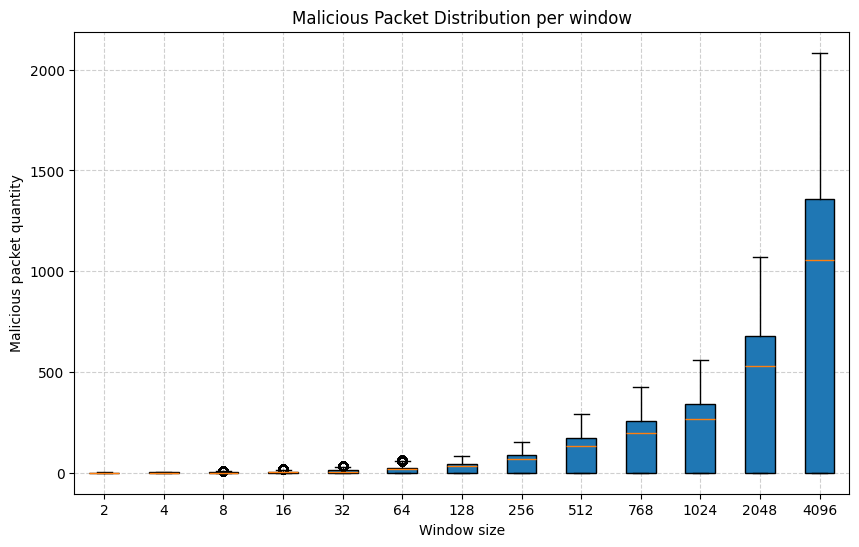

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Supondo que já exista:
# labels['label'] com valores "Normal" ou "Maligno"
desc = labels['label'].apply(lambda x: 0 if x == 'Normal' else 1).to_numpy()

windows = [2, 4, 8, 16, 32, 64, 128, 256, 512, 768, 1024, 2048, 4096]

# Guardar a contagem de pacotes malignos por janela em cada tamanho
malign_counts_per_window = []

for w in windows:
    # Cria janelas deslizantes
    desc_windows = np.lib.stride_tricks.sliding_window_view(desc, window_shape=w)
    # Soma de malignos em cada janela
    counts = desc_windows.sum(axis=1)
    malign_counts_per_window.append(counts)

# Boxplot
plt.figure(figsize=(10, 6))
plt.boxplot(malign_counts_per_window, labels=windows, patch_artist=True)

plt.xlabel("Window size")
plt.ylabel("Malicious packet quantity")
plt.title("Malicious Packet Distribution per window")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()
